In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn

**Load Dataset**

In [9]:
import pandas as pd

df = pd.read_csv('/content/data/citrus.csv')

print(df.head())

     name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9


**Data Understanding (EDA)**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [11]:
df.describe()

,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


In [12]:
print(df['name'].value_counts())


name
orange        5000
grapefruit    5000
Name: count, dtype: int64


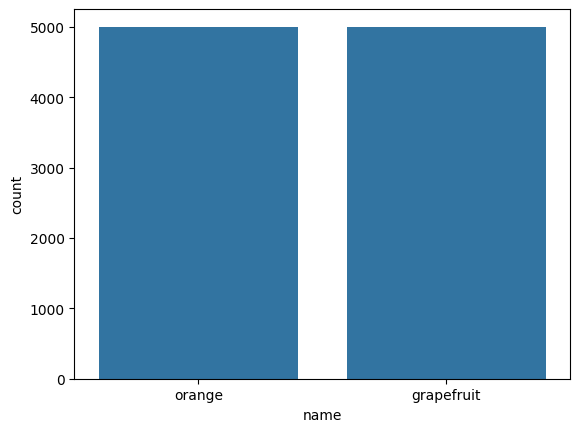

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='name', data=df)
plt.show()

**Data Preprocessing**

In [14]:
df.isnull().sum()

,0
name,0
diameter,0
weight,0
red,0
green,0
blue,0


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])

In [16]:
X = df.drop('name', axis=1)
y = df['name']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Modelling**

a. Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

b. Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

c. Support Vector Machine

In [21]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

**Evaluasi Model**

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate(nama, y_test, y_pred):
    print(f"\n=== {nama} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [23]:
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Naive Bayes", y_test, y_pred_nb)
evaluate("SVM", y_test, y_pred_svm)


=== Decision Tree ===
Accuracy: 0.944
Confusion Matrix:
 [[937  51]
 [ 61 951]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       988
           1       0.95      0.94      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000


=== Naive Bayes ===
Accuracy: 0.92
Confusion Matrix:
 [[919  69]
 [ 91 921]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       988
           1       0.93      0.91      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000


=== SVM ===
Accuracy: 0.937
Confusion Matrix:
 [[938  50]
 [ 76 936]]
Classification Report:
               precision    recall  f1-score 

**Improvement**

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 10, 'kernel': 'linear'}


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm, X, y, cv=5)
print(scores.mean())

0.8387
